In [40]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import glob
from scipy.io import readsav
from scipy.ndimage import zoom
from scipy.special import wofz
from functools import partial
from astropy import constants as const

In [ ]:
def voigt(lambda1, I_voigt, gamma_voigt, sigma_voigt):
    """
    Voigt 分量函数
    """
    z = (lambda1 + 1j * gamma_voigt) / (sigma_voigt * np.sqrt(2))
    voigt_component = np.real(wofz(z)) / (sigma_voigt * np.sqrt(2 * np.pi)) * I_voigt
    return voigt_component


def voigt_max_coefficient(gamma_voigt, sigma_voigt):
    """
    计算 Voigt 的最大系数，用于归一化
    """
    z_max = (1j * gamma_voigt) / (sigma_voigt * np.sqrt(2))
    return (sigma_voigt * np.sqrt(2 * np.pi)) / (np.real(wofz(z_max)))

# 单高斯 + Voigt + 常数
def voigt_single_cloud(lambda1, I_voigt, gamma_voigt, sigma_voigt,
                       I_cloud, mu_cloud, sigma_cloud, I_constant, S_l, I_0):

    # z = (lambda1 + 1j * gamma_voigt) / (sigma_voigt * np.sqrt(2))
    # voigt_component = np.real(wofz(z)) / (sigma_voigt * np.sqrt(2 * np.pi)) * I_voigt
    voigt_component = voigt(lambda1, I_voigt, gamma_voigt, sigma_voigt)
    tau1 = I_cloud * np.exp(-0.5*((lambda1 - mu_cloud) / sigma_cloud) ** 2)
    cloud_component = (S_l - I_0) * (1 - np.exp(-tau1))
    return voigt_component + cloud_component + I_constant
# 双高斯 + Voigt + 常数
def voigt_double_cloud(lambda1, I_voigt, gamma_voigt, sigma_voigt,
                       I_cloud1, mu_cloud1, sigma_cloud1,
                       I_cloud2, mu_cloud2, sigma_cloud2, I_constant):
    #双高斯的S_l和I_0是什么？
    # z = (lambda1 + 1j * gamma_voigt) / (sigma_voigt * np.sqrt(2))
    # voigt_component = np.real(wofz(z)) / (sigma_voigt * np.sqrt(2 * np.pi)) * I_voigt
    voigt_component = voigt(lambda1, I_voigt, gamma_voigt, sigma_voigt)
    tau1 = I_cloud1 * np.exp(-((lambda1 - mu_cloud1) / sigma_cloud1) ** 2)
    cloud_component1 = S_l * np.exp(-tau1)
    tau2 = I_cloud2 * np.exp(-((lambda1 - mu_cloud2) / sigma_cloud2) ** 2)
    cloud_component2 = S_l * np.exp(-tau2)
    return voigt_component + cloud_component1 + cloud_component2 + I_constant

In [46]:
#数据准备
#读取数据
dir=r'D:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\RSM20240618T211711_0000_HA.fits'
rsm=fits.open(dir)
spectrum=rsm[1].data[:,795,1521]
lam = rsm[1].header['CRVAL3'] + np.arange(rsm[1].header['NAXIS3']) * rsm[1].header['CDELT3']

#计算I_0
wavelength_point_list_ha_t0=lam
F_t0_l_TR=rsm[1].data[:,795,1521]
F_t0_l_TR_interpolated = interp1d(wavelength_point_list_ha_t0, F_t0_l_TR,
                                kind='cubic', fill_value='extrapolate')(
                                wavelength_point_list_ha_t0)
# TR_width = 70
# TR_height = 70
# psr = 1.0436
# r_fe=rsm[1].header['R_SUN']
# f_t0_lcont_TR=float(interp1d(wavelength_point_list_ha_t0, F_t0_l_TR,
#                               kind='cubic', fill_value='extrapolate')(6568))
# #这个I0是一小片区域相对于太阳整体的相对强度，我有必要用这种相对强度么
# I_0 = F_t0_l_TR_interpolated * (2 * TR_width / psr + 1) * (2 * TR_height / psr + 1) / (
#                 f_t0_lcont_TR * (2 * r_fe + 1) ** 2)
I_0=rsm[1].data[:,775:815,1501:1541].mean(axis=(1,2))
#待拟合数据
ha_left_index=50
ha_right_index=100
x_fit = lam[ha_left_index:ha_right_index + 1] - 6562.8 
y_fit = spectrum[ha_left_index:ha_right_index + 1]

In [47]:
#初始值设置
# Voigt 分量初值与范围
gamma_voigt_initial = 0.5
gamma_voigt_min, gamma_voigt_max = 0.0, 7

sigma_voigt_initial = 0.5
sigma_voigt_min, sigma_voigt_max = 0.0, 7

I_voigt_initial = 1.0 * np.max(y_fit) * voigt_max_coefficient(gamma_voigt_initial, sigma_voigt_initial)
I_voigt_min = 0.0
I_voigt_max = 5.0 * np.max(y_fit) * voigt_max_coefficient(gamma_voigt_initial, sigma_voigt_initial)


#单高斯分量初值设置
I_cloud_initial = 0.6 * np.min(y_fit)
I_cloud_min = 0.5 * np.min(y_fit)
I_cloud_max = 1.1 * np.max(y_fit)

mu_cloud_initial, mu_cloud_min, mu_cloud_max = 0.3, -1.0, 1.0
sigma_cloud_initial, sigma_cloud_min, sigma_cloud_max = 0.1, 0.01, 0.5


# 常数分量参数
I_constant_initial,I_constant_min,I_constant_max = 0.0,-0.001,0.002
S_l_initial,S_l_min,S_l_max = 0.003,0.001,1.0


In [57]:
#参数拟合
#定下来I0
voigt_single_cloud1 = partial(voigt_single_cloud, I_0=I_0[ha_left_index:ha_right_index + 1])

#拟合其他参数
popt, pcov = curve_fit(
    voigt_single_cloud1, x_fit, y_fit,
    p0=(I_voigt_initial, gamma_voigt_initial, sigma_voigt_initial,
        I_cloud_initial, mu_cloud_initial, sigma_cloud_initial,
        I_constant_initial,S_l_initial),
    bounds=(
        [I_voigt_min, gamma_voigt_min, sigma_voigt_min,
         I_cloud_min, mu_cloud_min, sigma_cloud_min,
         I_constant_min,S_l_min],
        [I_voigt_max, gamma_voigt_max, sigma_voigt_max,
         I_cloud_max, mu_cloud_max, sigma_cloud_max,
         I_constant_max,S_l_max]
    )
)

#提取参数
I_voigt_fit, gamma_voigt_fit, sigma_voigt_fit, \
I_cloud1_fit, mu_cloud1_fit, sigma_cloud1_fit, \
I_constant_fit,S_l_fit = popt

#计算多普勒速度
c = 3e5  # 光速 km/s
v1 = c * mu_cloud1_fit / 6562.8
#v2 = c * mu_cloud2_fit / 6562.8
print(f'谱线偏移{mu_cloud1_fit:.3f}'+'\u00C5')
print(f"Velocity component 1 = {v1:.3f} km/s")
print(popt)

谱线偏移0.086Å
Velocity component 1 = 3.952 km/s
[1.05529567e+04 7.08027601e-17 5.43749346e+00 1.72000000e+02
 8.64591946e-02 1.52805410e-01 2.00000000e-03 1.00000000e+00]


In [49]:
#画图
def cloud_component(I_cloud,lambda1,mu_cloud,sigma_cloud,S_l,I_0):
    tau1 = I_cloud * np.exp(-0.5*((lambda1 - mu_cloud) / sigma_cloud) ** 2)
    cloud_component = (S_l - I_0) * (1 - np.exp(-tau1))
    return cloud_component

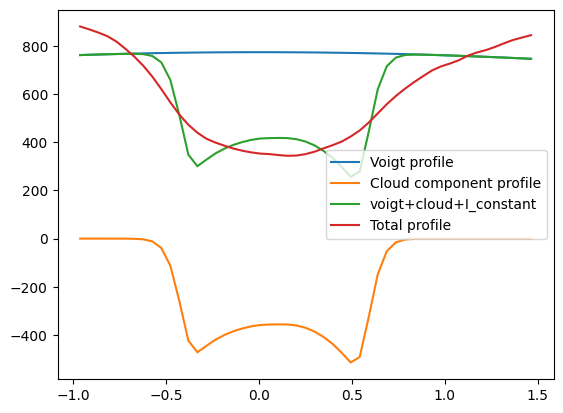

In [50]:
cloud_component1=cloud_component(I_cloud1_fit,x_fit,mu_cloud1_fit,
                                 sigma_cloud1_fit,S_l_fit,
                                 I_0[ha_left_index:ha_right_index + 1])
voigt1=voigt(x_fit,I_voigt_fit,gamma_voigt_fit,sigma_voigt_fit)

plt.plot(x_fit,voigt1,label='Voigt profile')
plt.plot(x_fit,cloud_component1,label='Cloud component profile')
plt.plot(x_fit,voigt1+cloud_component1+I_constant_fit,label='voigt+cloud+I_constant')
plt.plot(x_fit,y_fit,label='Total profile')
#plt.plot(x_fit,I_constant_fit,label='Constant component')
plt.legend()

In [92]:
def fit_single_all(paras,x_fit,y_fit,I_0):
    voigt_single_cloud1 = partial(voigt_single_cloud, I_0=I_0[ha_left_index:ha_right_index + 1])
    popt,pcov=curve_fit(
        voigt_single_cloud1,x_fit,y_fit,
        p0=paras[0::3],
        bounds=(paras[1::3],paras[2::3])
    )
    c=const.c
    v1=c.value*popt[4]/(6562.8*1000)
    print(f"Velocity component 1 = {v1:.3f} km/s")
    I_cloud1_fit=popt[3]
    mu_cloud1_fit=popt[4]
    sigma_cloud1_fit=popt[5]
    cloud_component1=cloud_component(I_cloud1_fit,x_fit,mu_cloud1_fit,
                                 sigma_cloud1_fit,S_l_fit,
                                 I_0[ha_left_index:ha_right_index + 1])
    voigt1=voigt(x_fit,I_voigt_fit,gamma_voigt_fit,sigma_voigt_fit)

    plt.plot(x_fit,voigt1,label='Voigt profile')
    plt.plot(x_fit,cloud_component1,label='Cloud component profile')
    plt.plot(x_fit,voigt1+cloud_component1+I_constant_fit,label='voigt+cloud+I_constant')
    plt.plot(x_fit,y_fit,label='Total profile')
    plt.legend()
    print(popt)
    return 

Velocity component 1 = 3.973 km/s
[1.05529567e+04 7.06807633e-01 7.00000000e+00 1.72000000e+02
 8.69748594e-02 1.52619343e-01 2.00000000e+02 3.44904471e+01]


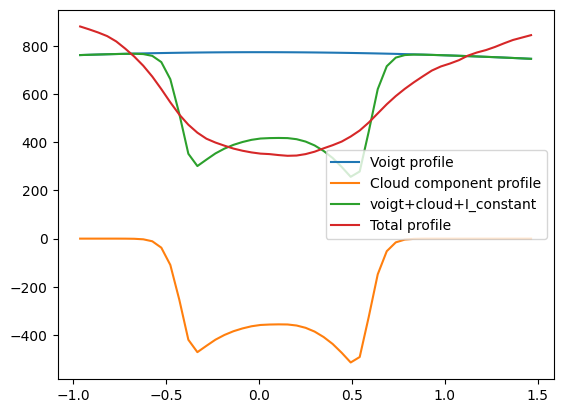

In [124]:
paras=np.zeros(24)
#3-5是gamma_voigt,initial,min,max
paras[3],paras[4],paras[5]=0.5,0,7
#6-8是sigma_voigt
paras[6],paras[7],paras[8]=0.5,0,7
#0-2是I_voigt
paras[0]= 1.0 * np.max(y_fit) * voigt_max_coefficient(paras[3], paras[6])
paras[1]= 0.0
paras[2]= 5.0 * np.max(y_fit) * voigt_max_coefficient(paras[3], paras[6])
#9-11是I_cloud
paras[9],paras[10],paras[11]=0.6*np.min(y_fit),0.5*np.min(y_fit),1.1*np.max(y_fit)
#12-14是mu_cloud
paras[12],paras[13],paras[14]=-0.5,-1.0,0.1
#15-17是sigma_cloud
paras[15],paras[16],paras[17]=0.15,0.001,0.25
#18-20是I_constant
paras[18],paras[19],paras[20]=0.0,-0.001,200
#21-23是S_l
paras[21],paras[22],paras[23]=0.003,0.001,100

I_0=rsm[1].data[:,775:815,1501:1541].mean(axis=(1,2))
#待拟合数据
ha_left_index=50
ha_right_index=100
x_fit = lam[ha_left_index:ha_right_index + 1] - 6562.8 
y_fit = spectrum[ha_left_index:ha_right_index + 1]
fit_single_all(paras,x_fit,y_fit,I_0)

In [120]:
from scipy.optimize import least_squares, differential_evolution
import numpy as np
from functools import partial
from scipy.special import wofz

def fit_single_all_improved(paras, x_fit, y_fit, I_0):
    """
    改进的拟合函数，使用更稳健的优化方法
    """
    voigt_single_cloud1 = partial(voigt_single_cloud, I_0=I_0[50:101])
    
    # 提取初始值和边界
    p0 = paras[0::3]  # 初始值
    lower_bounds = paras[1::3]  # 下界
    upper_bounds = paras[2::3]  # 上界
    bounds = (lower_bounds, upper_bounds)
    
    # 方法1: 使用最小二乘法（更稳健）
    def residual(params):
        return voigt_single_cloud1(x_fit, *params) - y_fit
    
    # 使用信任域反射算法（处理边界更好）
    result = least_squares(
        residual, 
        p0, 
        bounds=bounds,
        method='trf',  # 信任域反射算法
        loss='soft_l1',  # 对异常值更鲁棒
        f_scale=0.1,    # 尺度参数
        max_nfev=5000   # 增加函数评估次数
    )
    
    popt = result.x
    print(result.cost)
    print(0.1*np.var(y_fit))
    # 如果效果不好，尝试全局优化
    if result.cost > 0.1 * np.var(y_fit):  # 如果残差太大
        print("尝试全局优化...")
        global_result = differential_evolution(
            lambda params: np.sum(residual(params)**2),
            bounds=list(zip(lower_bounds, upper_bounds)),
            maxiter=1000,
            popsize=15,
            tol=1e-6
        )
        popt = global_result.x
    I_voigt_fit=popt[0]
    gamma_voigt_fit=popt[1]
    sigma_voigt_fit=popt[2]
    mu_cloud1_fit=popt[4]
    sigma_cloud1_fit=popt[5]
    S_l_fit=popt[7]
    
    cloud_component1=cloud_component(I_cloud1_fit,x_fit,mu_cloud1_fit,
                                 sigma_cloud1_fit,S_l_fit,
                                 I_0[ha_left_index:ha_right_index + 1])
    voigt1=voigt(x_fit,I_voigt_fit,gamma_voigt_fit,sigma_voigt_fit)

    plt.plot(x_fit,voigt1,label='Voigt profile')
    plt.plot(x_fit,cloud_component1,label='Cloud component profile')
    plt.plot(x_fit,voigt1+cloud_component1+I_constant_fit,label='voigt+cloud+I_constant')
    plt.plot(x_fit,y_fit,label='Total profile')
    plt.legend()
    return popt

458.1619169963985
3496.636524413687


array([3.23797956e+03, 6.85543382e-02, 1.88919079e+00, 1.76753755e+02,
       6.56560320e-02, 1.45440499e-01, 1.12948993e+02, 2.80899445e+00])

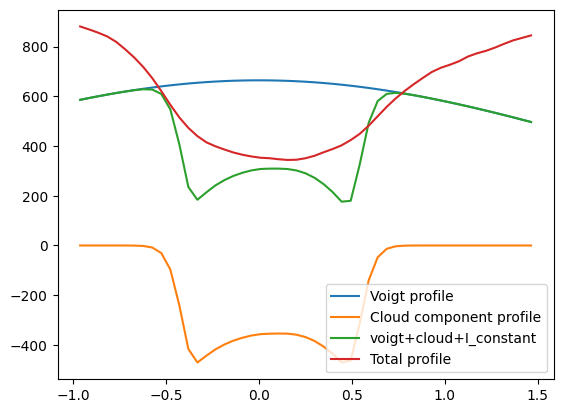

In [121]:
fit_single_all_improved(paras, x_fit, y_fit, I_0)